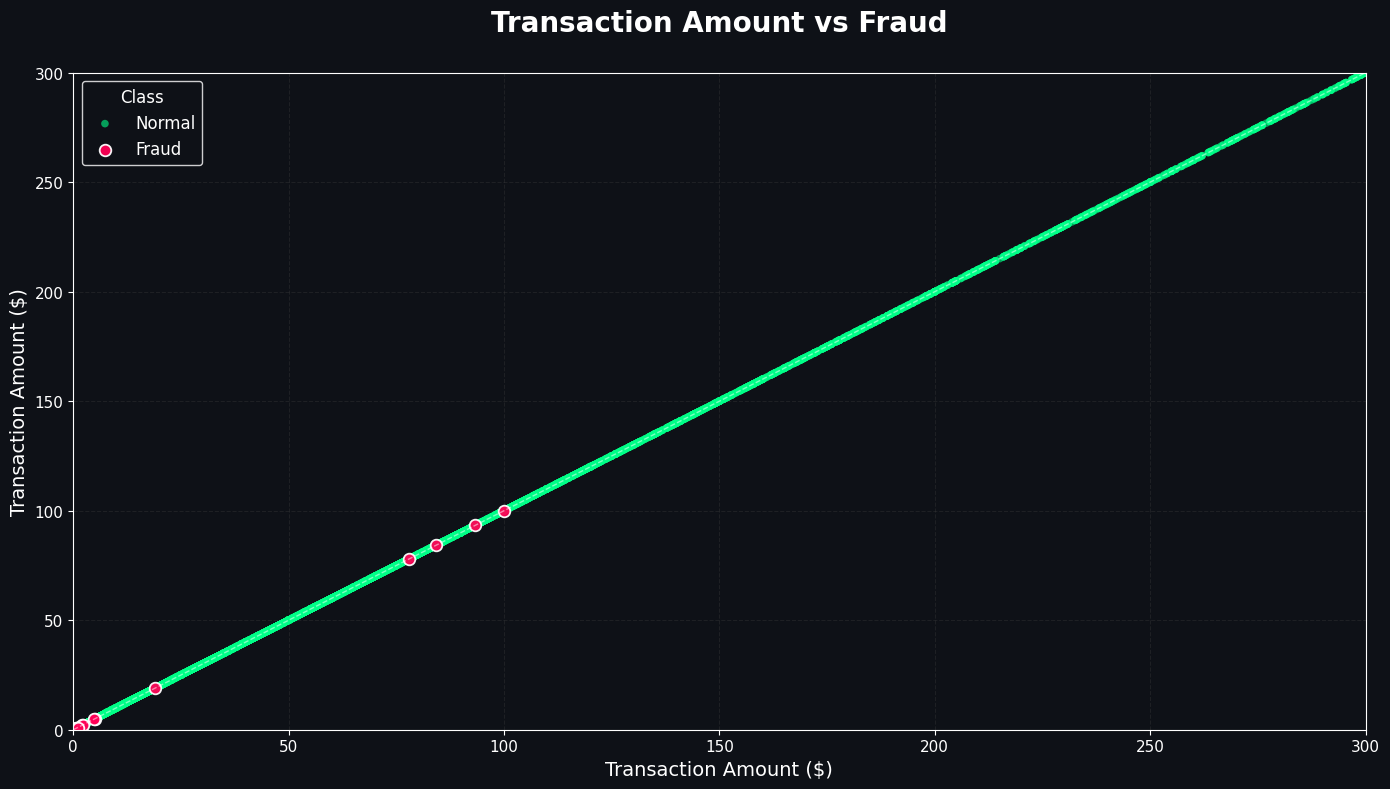

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



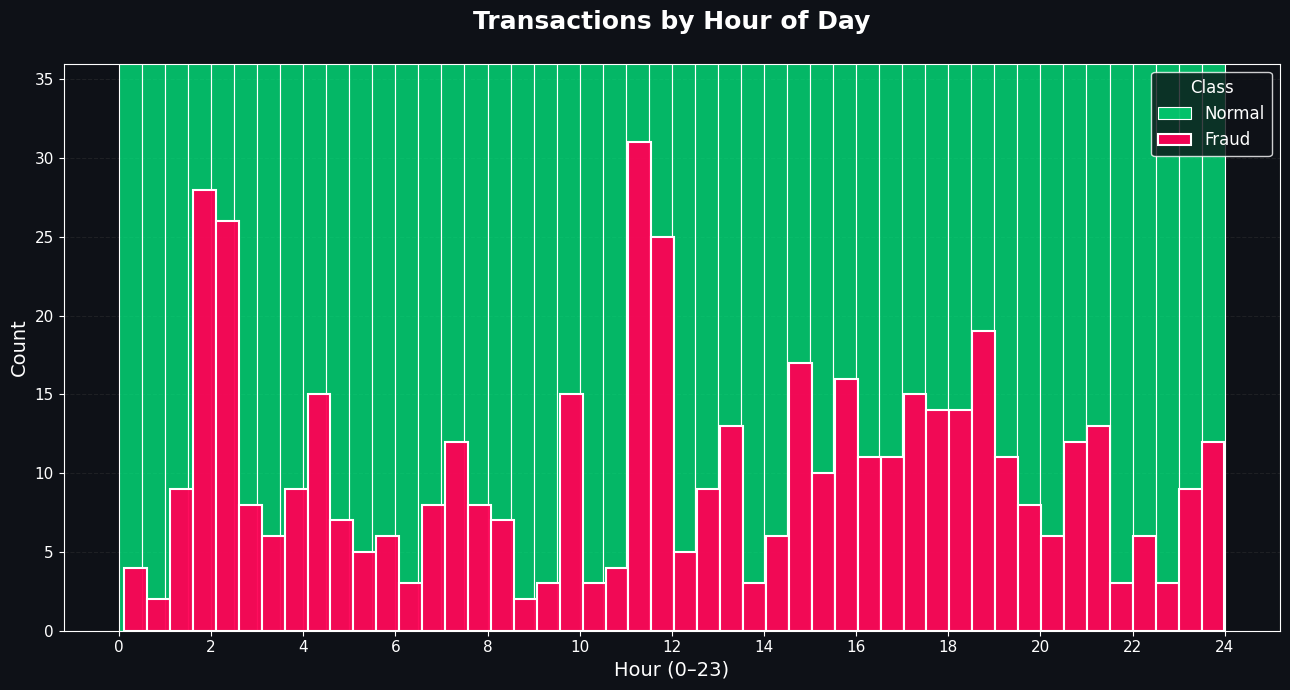

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly
import plotly.graph_objects as go
import importlib
from sklearn.preprocessing import RobustScaler


BASE_DIR = r"D:\2"
RAW_PATH = os.path.join(BASE_DIR, "data", "raw", "creditcard.csv")
PROC_DIR = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(PROC_DIR, exist_ok=True)

data = pd.read_csv(RAW_PATH)

#plot for class distribution
class_count = data['Class'].value_counts().reset_index()
class_count.columns = ['Class','Count']
class_count['Class'] = class_count['Class'].map({0: 'Non-Fraud', 1: 'Fraud '})

fig = px.bar(class_count, x ='Class', y = 'Count', text = 'Count',
             title = 'Class Distribution (Fraud Vs Non-Fraud)',
             labels = {'Class': 'Class', 'Count': 'Count'},
             template = 'plotly_dark',
             color_discrete_sequence = ["#AAAEE2", "#C9938A"])

fig.update_traces(textposition= 'auto')
fig.write_image(r"D:\2\output\class_distribution.jpg")
fig.show()

#Amount distribution histogram
fig_amount = px.histogram(data, x = 'Amount', nbins = 50,
                          title = 'Amount Distribution',
                          labels = {'Amount': 'Transaction Amount'},
                          template = 'plotly_dark',
                          color_discrete_sequence = ['lightblue'])
fig_amount.update_layout(bargap = 0.1) 
fig_amount.write_image(r"D:\2\output\amount_distribution.jpg")
fig_amount.show()   

#Time distribution histogram
fig_time = px.histogram(data, x = 'Time', nbins = 50,
                          title = 'Time Distribution',
                          labels = {'Time': 'Transaction Time (in seconds)'},
                          template = 'plotly_dark',
                          color_discrete_sequence = ['lightgreen'])
fig_time.update_layout(bargap = 0.1) 
fig_time.write_image(r"D:\2\output\time_distribution.jpg")
fig_time.show()   

#Amount vs Fraud Scatter Plot
df_plot = data.sample(n=15000, random_state=42)
normal = df_plot[df_plot['Class'] == 0]
fraud = df_plot[df_plot['Class'] == 1]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0e1117')
ax.set_facecolor('#0e1117')

ax.scatter(normal['Amount'], normal['Amount'], 
           c='#00ff88', alpha=0.6, s=30, label='Normal', edgecolors='none')

ax.scatter(fraud['Amount'], fraud['Amount'], 
           c='#ff0055', alpha=0.95, s=70, label='Fraud', 
           edgecolors='white', linewidth=1.3)

ax.set_xlim(0, 300)  
ax.set_ylim(0, 300)

ax.plot([0, 300], [0, 300], '--', color='white', alpha=0.5, linewidth=1)

ax.set_title('Transaction Amount vs Fraud', 
             fontsize=20, fontweight='bold', color='white', pad=30)
ax.set_xlabel('Transaction Amount ($)', fontsize=14, color='white')
ax.set_ylabel('Transaction Amount ($)', fontsize=14, color='white')

ax.grid(True, alpha=0.3, color='#444444', linestyle='--')
ax.set_axisbelow(True)

ax.legend(title='Class', title_fontsize=12, fontsize=12,
          facecolor='#0e1117', edgecolor='white', labelcolor='white', loc='upper left')

ax.tick_params(colors='white', labelsize=11)
ax.set_xticks(range(0, 301, 50))
ax.set_yticks(range(0, 301, 50))

save_path = r"D:\2\output\amount_vs_fraud_linear.jpg"
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#0e1117')
plt.show()



#Capping oulier in 'Amount' by upper and lower quantiles
lower = data["Amount"].quantile(0.005)
upper = data["Amount"].quantile(0.995)
data["Amount_capped"] = np.clip(data["Amount"], lower, upper)

#Log transformation of "Amount Capped"
data["Amount_log"] = np.log1p(data["Amount_capped"])

#Cyclic enscoding of 'Time'
data["Time_hours"] = (data["Time"] % (24 * 3600)) / 3600
data["Time_sin"] = np.sin(2 * np.pi * data["Time_hours"] / 24)
data["Time_cos"] = np.cos(2 * np.pi * data["Time_hours"] / 24)

#Interactional Features
data["Amount_V10_interaction"] = data["Amount_log"] * data["V10"]
data["Time_V12_interaction"] = data["Time_sin"] * data["V12"]


features_to_scale = (
    ["Amount_log", "Time_sin", "Time_cos",
     "Amount_V10_interaction", "Time_V12_interaction"] +
    [f"V{i}" for i in range(1, 29)]
)

X = data[features_to_scale].copy()
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=features_to_scale, index=data.index)
scaled_df["Class"] = data["Class"]

# Plot transactions by hour of day
import matplotlib.pyplot as plt
import seaborn as sns

scaled_df['hour'] = (data['Time'] % 86400) / 3600  # ← FIXED: use scaled_df

normal = scaled_df[scaled_df['Class'] == 0]
fraud = scaled_df[scaled_df['Class'] == 1]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0e1117')
ax.set_facecolor('#0e1117')

sns.histplot(
    data=normal, x='hour', bins=48, alpha=0.7,
    color='#00ff88', label='Normal', ax=ax,
    edgecolor='white', linewidth=0.8
)

sns.histplot(
    data=fraud, x='hour', bins=48, alpha=0.95,
    color='#ff0055', label='Fraud', ax=ax,
    edgecolor='white', linewidth=1.5
)

max_fraud = fraud['hour'].value_counts().max()
ax.set_ylim(0, max_fraud * 6)  

ax.set_title('Transactions by Hour of Day', 
             fontsize=18, fontweight='bold', color='white', pad=25)
ax.set_xlabel('Hour (0–23)', fontsize=14, color='white')
ax.set_ylabel('Count', fontsize=14, color='white')

ax.legend(title='Class', title_fontsize=12, fontsize=12,
          facecolor='#0e1117', edgecolor='white', labelcolor='white')

ax.grid(True, alpha=0.3, color='#444444', linestyle='--')
ax.set_axisbelow(True)

ax.tick_params(colors='white', labelsize=11)
ax.set_xticks(range(0, 25, 2))

plt.tight_layout()

save_path = r"D:\2\output\hour_of_day.jpg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='#0e1117')
plt.show()



out_path = os.path.join(PROC_DIR, "scaled_features.pkl")
scaled_df.to_pickle(out_path)


In [4]:
features_to_scale = [
    "Amount_log", "Time_sin", "Time_cos",
    "Amount_V10_interaction", "Time_V12_interaction"
] + [f"V{i}" for i in range(1, 29)]

In [ ]:

# After scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(data[features_to_scale])

# SAVE SCALER
joblib.dump(scaler, r"D:\2\data\processed\robust_scaler.pkl")
print("Scaler saved: 33 features")

Scaler saved: 33 features


In [8]:
import pandas as pd

df = pd.read_pickle(r"D:\2\data\processed\scaled_features.pkl")
print("Scaled DF shape =", df.shape)

print("Feature count =", df.drop("Class", axis=1).shape[1])


Scaled DF shape = (284807, 35)
Feature count = 34


In [9]:
import joblib

scaler = joblib.load(r"D:\2\data\processed\robust_scaler.pkl")
print("Scaler expects =", scaler.n_features_in_)


Scaler expects = 33


In [10]:
import pandas as pd
import joblib
from sklearn.preprocessing import RobustScaler

df = pd.read_pickle(r"D:\2\data\processed\scaled_features.pkl")
X = df.drop("Class", axis=1)

scaler = RobustScaler()
scaler.fit(X)

joblib.dump(scaler, r"D:\2\data\processed\robust_scaler.pkl")

print("New scaler saved! Feature count =", scaler.n_features_in_)


New scaler saved! Feature count = 34
